<a href="https://colab.research.google.com/github/Mahdi-Saadati/Artificial-Intelligence-workshop/blob/main/9.%20Reading%20an%20EEG%20Signal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" align="right">

خواندن یک سیگنال EEG

اگر هدفتان این است که بدون دانلود دستی فایل‌ها، یک دیتاست EEG را مستقیماً از کتابخانه‌های پایتون دریافت کنید و سپس یک تحلیل ساده روی آن انجام دهید، کتابخانه ‌MNE-Python بهترین گزینه است. این کتابخانه چندین دیتاست EEG/MEG آماده دارد که به‌صورت خودکار دانلود می‌شوند.

فرض کنید مغز انسان مثل یک ارکستر بزرگ موسیقی است. دستگاه EEG مثل یک میکروفون خیلی حساس است که صدای این ارکستر را ضبط می‌کند. کد زیر این صداها را می‌گیرد، تمیز می‌کند و بعد بررسی می‌کند که مغز چه کارهایی انجام داده است.

نمونه کد زیر:

یک فایل EEG آماده را از اینترنت دانلود می‌کند.

سیگنال‌های مغز را می‌خواند.

صداهای مزاحم و نویزها را کم می‌کند.

پلک زدن و حرکت چشم (آرتیفکت‌های چشم (EOG)) را تا حدی حذف می‌کند.

لحظه‌های مهم آزمایش را پیدا می‌کند.

سیگنال‌های مربوط به هر اتفاق را جدا می‌کند

میانگین آنها را می‌گیرد.

نمودار می‌کشد تا ببینیم مغز چه کرده است.


In [ ]:
!pip install mne

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m05s (2.5 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Filtering raw data in 1 co

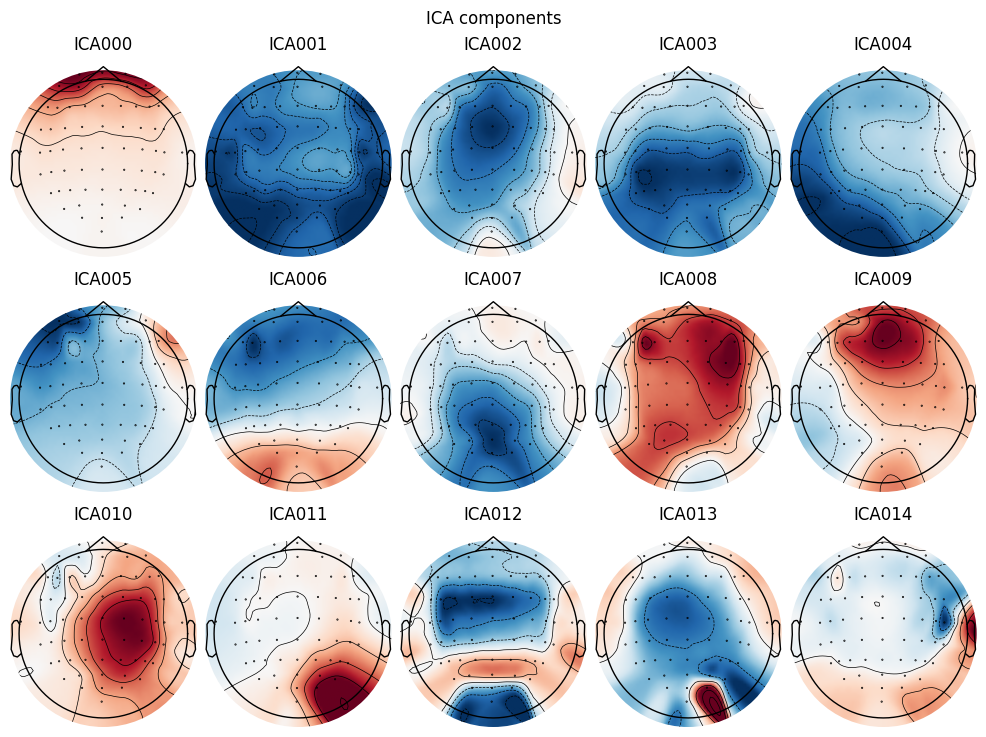

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 64 PCA components
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event IDs:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Not setting metadata
30 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 161 original time points ...
1 bad epochs dropped
<Epochs | 29 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~2.4 MiB, data loaded,
 np.str_('T0'): 14
 np.str_('T1'): 7
 np.str_('T2'): 8>


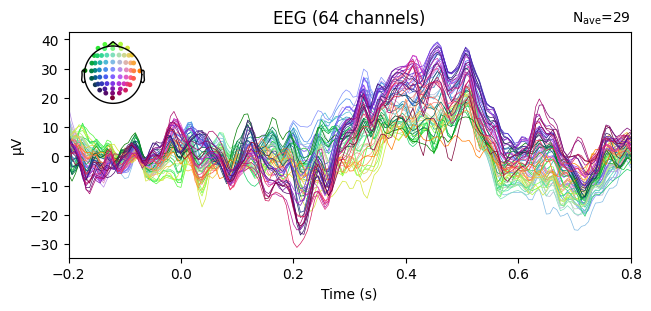

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Using matplotlib as 2D backend.


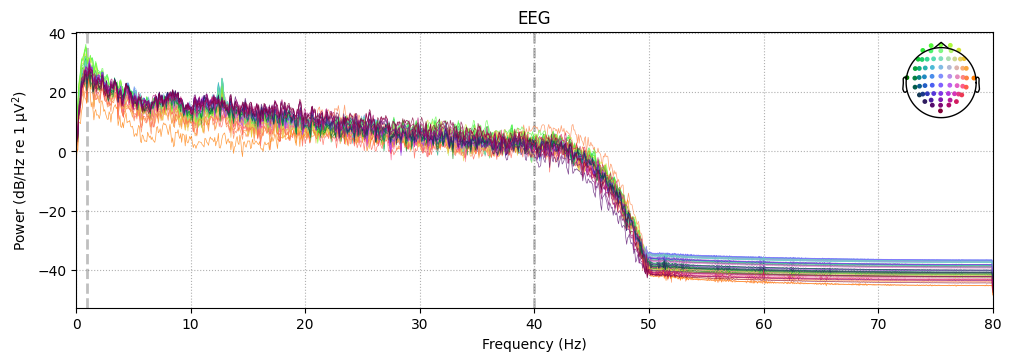

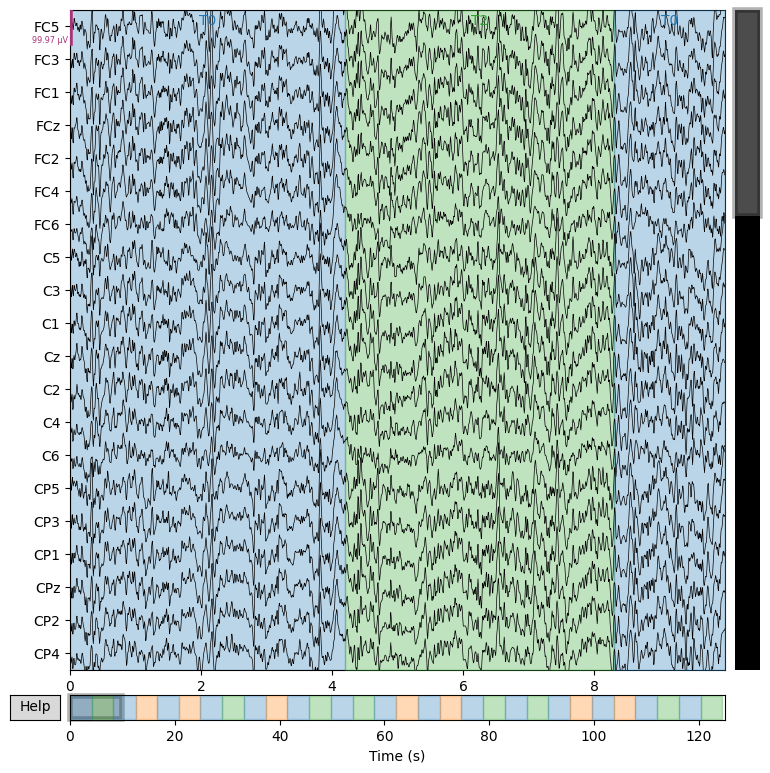

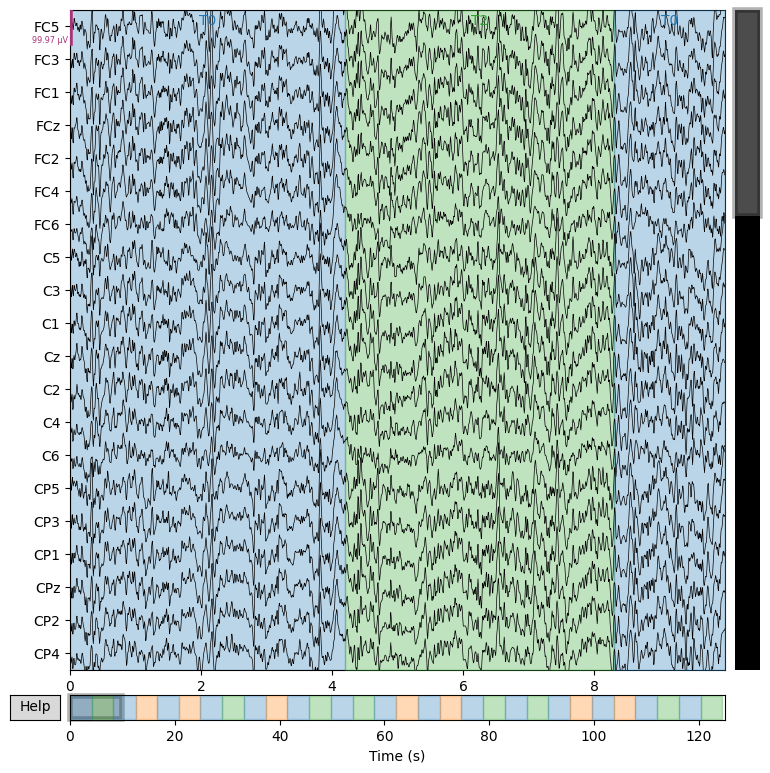

In [2]:
import mne                               # وارد کردن کتابخانه MNE برای تحلیل EEG
from mne.datasets import eegbci          # ابزار دانلود دیتاست EEG
from mne.preprocessing import ICA        # ابزار حذف نویز با ICA

subject = 1                              # انتخاب شرکت‌کننده شماره 1
runs = [6]                               # انتخاب آزمایش شماره 6

files = eegbci.load_data(subject, runs)  # دانلود دیتاست EEG از اینترنت

raw = mne.io.read_raw_edf(
    files[0],
    preload=True
)                                        # باز کردن فایل EEG و بارگذاری آن در حافظه

mne.datasets.eegbci.standardize(raw)     # استاندارد کردن نام کانال‌های EEG

raw.set_montage("standard_1005")         # تعیین محل الکترودها روی سر

print(raw.info)                          # نمایش اطلاعات فایل EEG

raw.filter(
    l_freq=1,
    h_freq=40
)                                        # حذف نویزها و نگه داشتن فرکانس‌های 1 تا 40 هرتز

ica = ICA(
    n_components=15,                     # تقسیم سیگنال به 15 مؤلفه
    random_state=97,                     # تولید نتایج یکسان در هر اجرا
    max_iter="auto"                      # تعیین خودکار تعداد تکرارها
)

ica.fit(raw)                             # یادگیری الگوهای موجود در سیگنال

ica.plot_components()                    # نمایش مؤلفه‌های استخراج‌شده

raw_clean = ica.apply(
    raw.copy()
)                                        # حذف نویزها از یک کپی از داده

events, event_id = mne.events_from_annotations(
    raw_clean
)                                        # استخراج رویدادهای ثبت‌شده در آزمایش

print("Event IDs:")                      # چاپ عنوان رویدادها
print(event_id)                          # چاپ شناسه هر رویداد

epochs = mne.Epochs(
    raw_clean,                           # داده تمیزشده
    events,                              # رویدادهای پیدا شده
    event_id=event_id,                   # شناسه رویدادها
    tmin=-0.2,                           # 0.2 ثانیه قبل از رویداد
    tmax=0.8,                            # 0.8 ثانیه بعد از رویداد
    baseline=(None, 0),                  # تعیین خط پایه
    preload=True                         # بارگذاری داده در حافظه
)

print(epochs)                            # نمایش اطلاعات Epochها

evoked = epochs.average()                # محاسبه میانگین همه Epochها (ERP)

evoked.plot()                            # رسم نمودار ERP

raw_clean.compute_psd().plot()           # رسم طیف توان فرکانسی سیگنال

raw_clean.plot(
    duration=10,                         # نمایش 10 ثانیه از داده
    n_channels=20,                       # نمایش 20 کانال EEG
    scalings="auto"                      # تنظیم خودکار مقیاس نمودار
)

<div dir="rtl" align="right">

خلاصه خیلی ساده

این برنامه دقیقاً مثل یک دانشمند کوچک عمل می‌کند:

📥 EEG را دانلود می‌کند.

🧹 داده‌ها را تمیز می‌کند.

👁️ نویزهای ناشی از پلک زدن را حذف می‌کند.

✂️ داده را به قسمت‌های کوچک تقسیم می‌کند.

📊 میانگین می‌گیرد.

📈 نمودار رسم می‌کند.

🧠 در نهایت به ما کمک می‌کند بفهمیم مغز هنگام انجام یک کار چگونه فعالیت کرده است.


تحلیل‌های دیگری که می‌توانید روی همین دیتاست انجام دهید
تحلیل فرکانسی (FFT)

محاسبه توان باندهای Delta, Theta, Alpha, Beta, Gamma

طبقه‌بندی Motor Imagery

استفاده از CSP و SVM

تشخیص حرکت دست چپ و راست

تحلیل ERP

استخراج مؤلفه‌های P300، N200 و ...

اتصال عملکردی مغز (Functional Connectivity)

Coherence

Phase Locking Value (PLV)

یادگیری عمیق

CNN

EEGNet

Transformer
